<a href="https://colab.research.google.com/github/isumakm/Weather-Prediction-and-Crop-Recommendation-System-/blob/Single-Crop-Analysis/model_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 06. Model Comparison: Random Forest vs. XGBoost vs. MLP

In this notebook we compare the three models trained in the previous notebooks:
- Random Forest
- XGBoost
- Multi‑Layer Perceptron (MLP)

We will:
- Load the saved models and the preprocessor.
- Generate predictions on the test set.
- Compare performance metrics (accuracy, precision, recall, F1, ROC‑AUC, Average Precision).
- Plot ROC curves and Precision‑Recall curves together.
- Create a summary table and bar chart.
- Discuss the results and choose the best model for deployment.

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score,
                             roc_curve, precision_recall_curve)
from sklearn.model_selection import train_test_split
import joblib
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
%matplotlib inline

1. Load Data and Preprocessor

In [ ]:
# Load original data
df = pd.read_csv('Crop_training_data_FULL _1.csv')

# Separate features and target
X = df.drop(columns=['suitability', 'suitability_class', 'texture'])
y = df['suitability_class'].map({'Suitable': 1, 'Unsuitable': 0})

# Load preprocessor
preprocessor = joblib.load('models/preprocessor.pkl')

# Transform data
X_processed = preprocessor.transform(X)

# Recreate train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42, stratify=y
)

print("Test set size:", X_test.shape)

Test set size: (420, 31)


2. Load the Three Models

In [ ]:
# Load models
rf_model = joblib.load('models/random_forest_best.pkl')
xgb_model = joblib.load('models/xgboost_best.pkl')
mlp_model = joblib.load('models/mlp_best.pkl')

print("Models loaded successfully.")

Models loaded successfully.


3. Generate Predictions and Probabilities

In [ ]:
# Random Forest
rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

# XGBoost
xgb_pred = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

# MLP
mlp_pred = mlp_model.predict(X_test)
mlp_proba = mlp_model.predict_proba(X_test)[:, 1]

4. Compute Performance Metrics

In [ ]:
metrics = {
    'Model': ['Random Forest', 'XGBoost', 'MLP'],
    'Accuracy': [
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred),
        accuracy_score(y_test, mlp_pred)
    ],
    'Precision': [
        precision_score(y_test, rf_pred),
        precision_score(y_test, xgb_pred),
        precision_score(y_test, mlp_pred)
    ],
    'Recall': [
        recall_score(y_test, rf_pred),
        recall_score(y_test, xgb_pred),
        recall_score(y_test, mlp_pred)
    ],
    'F1 Score': [
        f1_score(y_test, rf_pred),
        f1_score(y_test, xgb_pred),
        f1_score(y_test, mlp_pred)
    ],
    'ROC AUC': [
        roc_auc_score(y_test, rf_proba),
        roc_auc_score(y_test, xgb_proba),
        roc_auc_score(y_test, mlp_proba)
    ],
    'Avg Precision': [
        average_precision_score(y_test, rf_proba),
        average_precision_score(y_test, xgb_proba),
        average_precision_score(y_test, mlp_proba)
    ]
}

results_df = pd.DataFrame(metrics)
results_df = results_df.round(4)
print(results_df.to_string(index=False))

        Model  Accuracy  Precision  Recall  F1 Score  ROC AUC  Avg Precision
Random Forest    0.7881     0.7971  0.6433    0.7120   0.8724         0.8267
      XGBoost    0.8333     0.8024  0.7836    0.7929   0.9097         0.8765
          MLP    0.8429     0.8107  0.8012    0.8059   0.9165         0.8875


5. ROC Curves

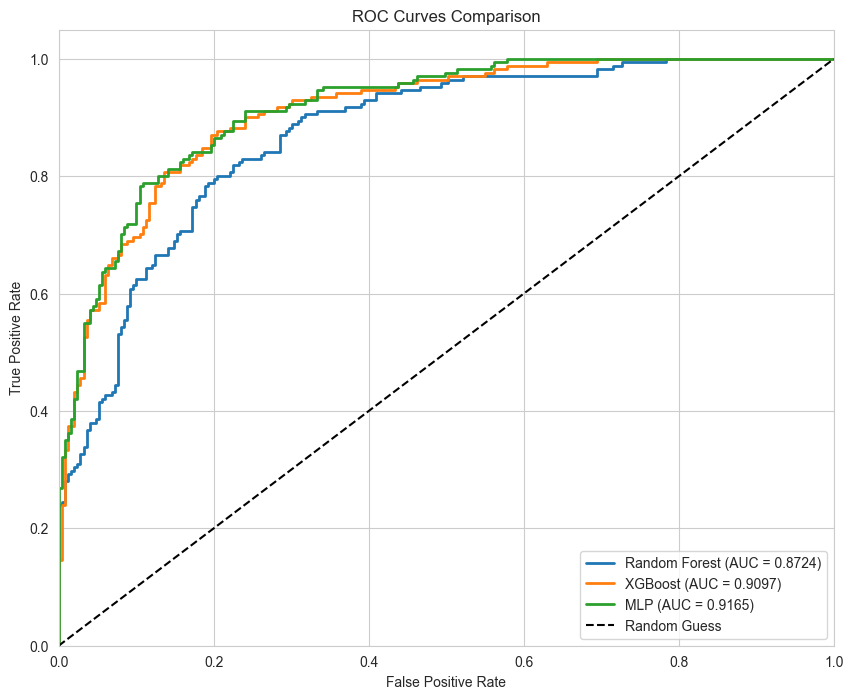

In [ ]:
plt.figure(figsize=(10, 8))

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_proba)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(y_test, rf_proba):.4f})', lw=2)

# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_proba)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_score(y_test, xgb_proba):.4f})', lw=2)

# MLP
fpr_mlp, tpr_mlp, _ = roc_curve(y_test, mlp_proba)
plt.plot(fpr_mlp, tpr_mlp, label=f'MLP (AUC = {roc_auc_score(y_test, mlp_proba):.4f})', lw=2)

# Diagonal line
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

6. Precision‑Recall Curves

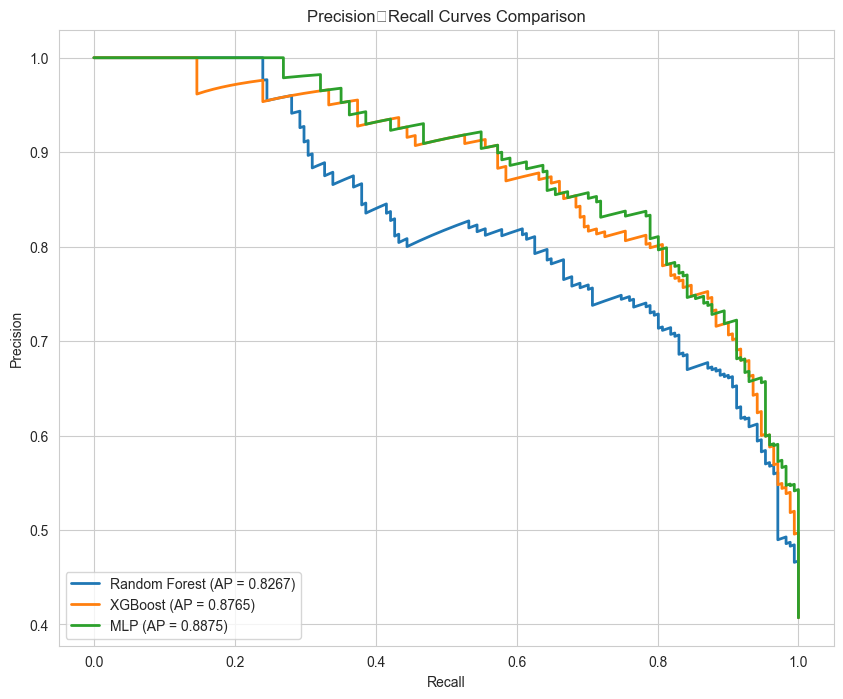

In [ ]:
plt.figure(figsize=(10, 8))

# Random Forest
precision_rf, recall_rf, _ = precision_recall_curve(y_test, rf_proba)
ap_rf = average_precision_score(y_test, rf_proba)
plt.plot(recall_rf, precision_rf, label=f'Random Forest (AP = {ap_rf:.4f})', lw=2)

# XGBoost
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, xgb_proba)
ap_xgb = average_precision_score(y_test, xgb_proba)
plt.plot(recall_xgb, precision_xgb, label=f'XGBoost (AP = {ap_xgb:.4f})', lw=2)

# MLP
precision_mlp, recall_mlp, _ = precision_recall_curve(y_test, mlp_proba)
ap_mlp = average_precision_score(y_test, mlp_proba)
plt.plot(recall_mlp, precision_mlp, label=f'MLP (AP = {ap_mlp:.4f})', lw=2)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision‑Recall Curves Comparison')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

7. Bar Chart Comparison

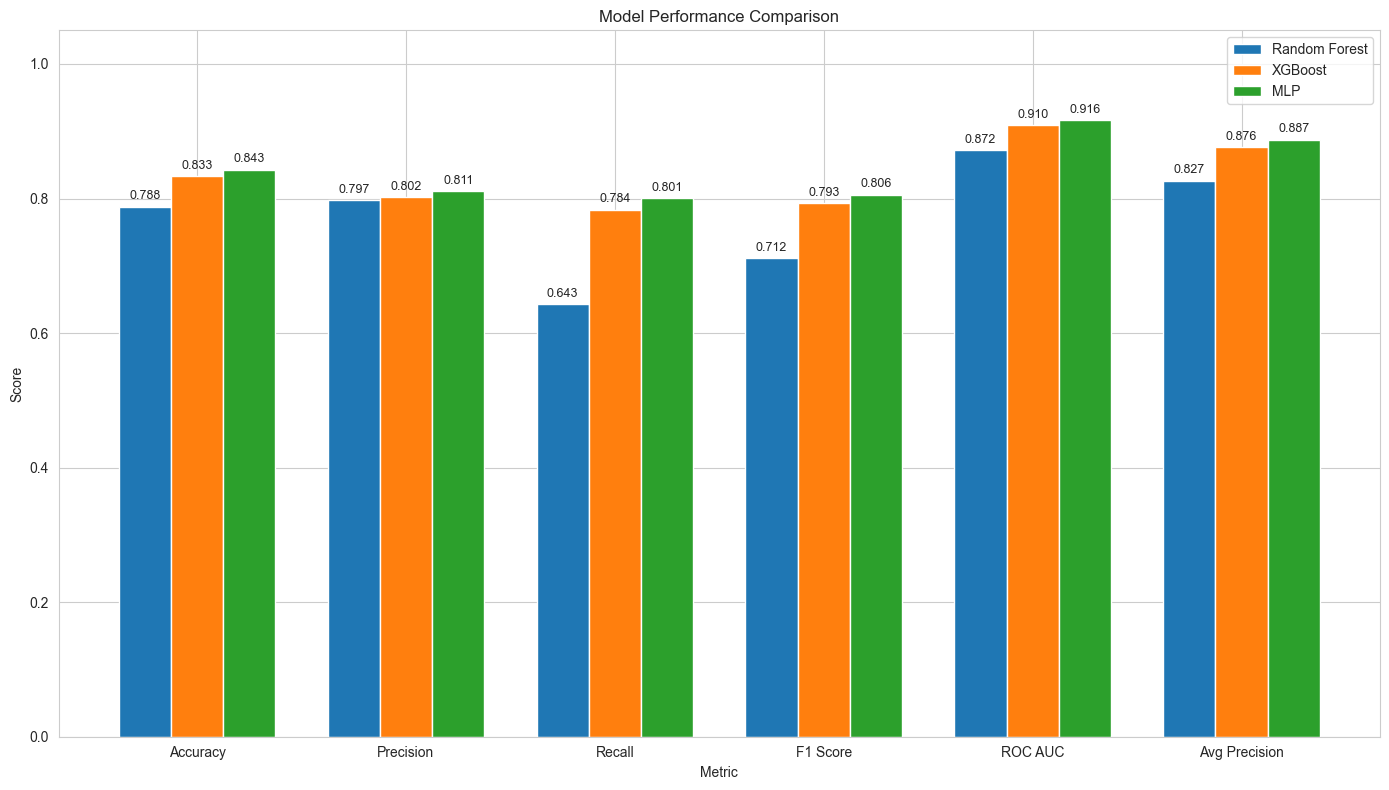

In [ ]:
# Prepare data for bar chart
metrics_for_plot = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC', 'Avg Precision']
x = np.arange(len(metrics_for_plot))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 8))

bars1 = ax.bar(x - width, results_df.loc[0, metrics_for_plot].values, width, label='Random Forest')
bars2 = ax.bar(x, results_df.loc[1, metrics_for_plot].values, width, label='XGBoost')
bars3 = ax.bar(x + width, results_df.loc[2, metrics_for_plot].values, width, label='MLP')

ax.set_xlabel('Metric')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(metrics_for_plot)
ax.legend()
ax.set_ylim(0, 1.05)

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()